<a href="https://colab.research.google.com/github/Tanish-ops7710/DAFA1/blob/main/FA2Q3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ZIP file found: /content/store-sales-time-series-forecasting.zip
Dataset extracted successfully.

Train files found: 1
Using: /content/store_sales_data/train.csv

Dataset Shape: (3000888, 6)

First 5 rows:
   id        date  store_nbr      family  sales  onpromotion
0   0  2013-01-01          1  AUTOMOTIVE    0.0            0
1   1  2013-01-01          1   BABY CARE    0.0            0
2   2  2013-01-01          1      BEAUTY    0.0            0
3   3  2013-01-01          1   BEVERAGES    0.0            0
4   4  2013-01-01          1       BOOKS    0.0            0

Missing Values:
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Index: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3

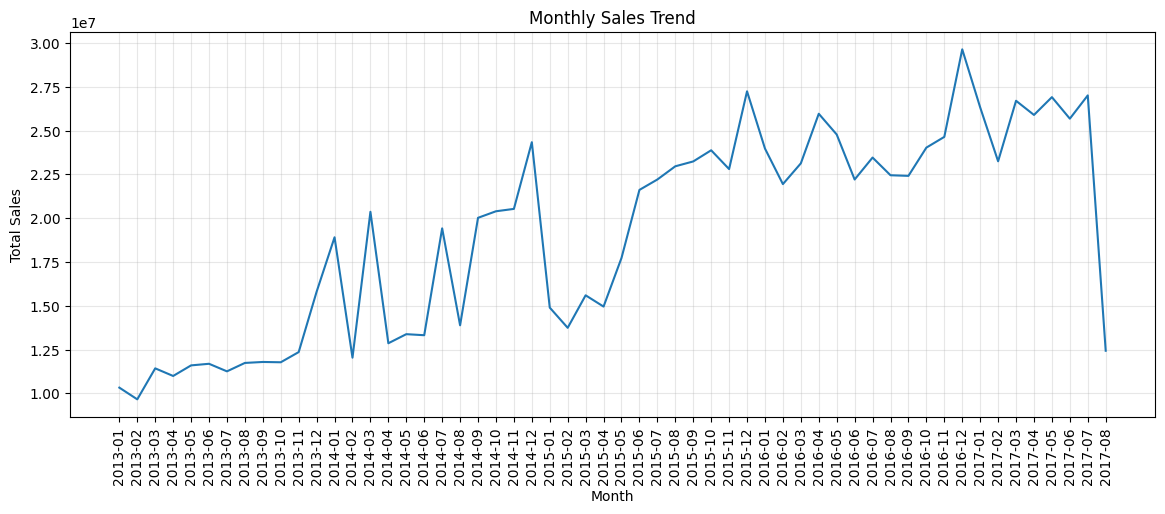


TOP 10 PRODUCT FAMILIES
family
GROCERY I        3.434627e+08
BEVERAGES        2.169545e+08
PRODUCE          1.227047e+08
CLEANING         9.752129e+07
DAIRY            6.448771e+07
BREAD/BAKERY     4.213395e+07
POULTRY          3.187600e+07
MEATS            3.108647e+07
PERSONAL CARE    2.459205e+07
DELI             2.411032e+07
Name: sales, dtype: float64


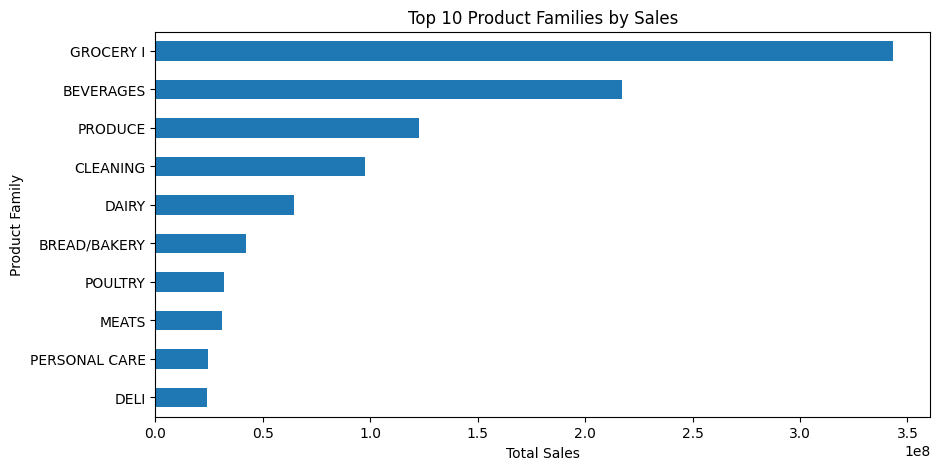

In [1]:
# ==========================================
# Q3 - STEP 1
# LOAD + PREPROCESS + SALES ANALYSIS
# ==========================================

import os
import glob
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------
# 1. Find uploaded ZIP / CSV files
# ------------------------------------------

zip_files = glob.glob('/content/*.zip')

if zip_files:
    print("ZIP file found:", zip_files[0])

    extract_path = '/content/store_sales_data'
    os.makedirs(extract_path, exist_ok=True)

    with zipfile.ZipFile(zip_files[0], 'r') as z:
        z.extractall(extract_path)

    print("Dataset extracted successfully.")

# Find train.csv anywhere in /content
train_files = glob.glob(
    '/content/**/train.csv',
    recursive=True
)

print("\nTrain files found:", len(train_files))

if len(train_files) == 0:
    raise FileNotFoundError(
        "train.csv not found. Please upload the Kaggle dataset."
    )

train_path = train_files[0]
print("Using:", train_path)

# ------------------------------------------
# 2. Load data
# ------------------------------------------

df = pd.read_csv(train_path)

print("\nDataset Shape:", df.shape)

print("\nFirst 5 rows:")
print(df.head())

# ------------------------------------------
# 3. Preprocessing
# ------------------------------------------

df['date'] = pd.to_datetime(df['date'])

df = df.sort_values('date')

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Basic information
print("\nDataset Information:")
print(df.info())

# ------------------------------------------
# 4. Sales summary
# ------------------------------------------

print("\nSALES SUMMARY")
print("=" * 50)

print(df['sales'].describe())

print("\nNumber of Stores:", df['store_nbr'].nunique())
print("Number of Families:", df['family'].nunique())
print("Date Range:", df['date'].min(), "to", df['date'].max())

# ------------------------------------------
# 5. Monthly sales trend
# ------------------------------------------

monthly_sales = (
    df.groupby(df['date'].dt.to_period('M'))['sales']
    .sum()
)

plt.figure(figsize=(14, 5))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=90)
plt.grid(alpha=0.3)

plt.show()

# ------------------------------------------
# 6. Top 10 product families
# ------------------------------------------

top_families = (
    df.groupby('family')['sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTOP 10 PRODUCT FAMILIES")
print(top_families)

plt.figure(figsize=(10, 5))

top_families.sort_values().plot(kind='barh')

plt.title('Top 10 Product Families by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product Family')

plt.show()

Training samples: 1324
Testing samples : 332

SALES FORECASTING RESULTS
MAPE: 33.61%
MAPE is above 10%; model will be improved if required.


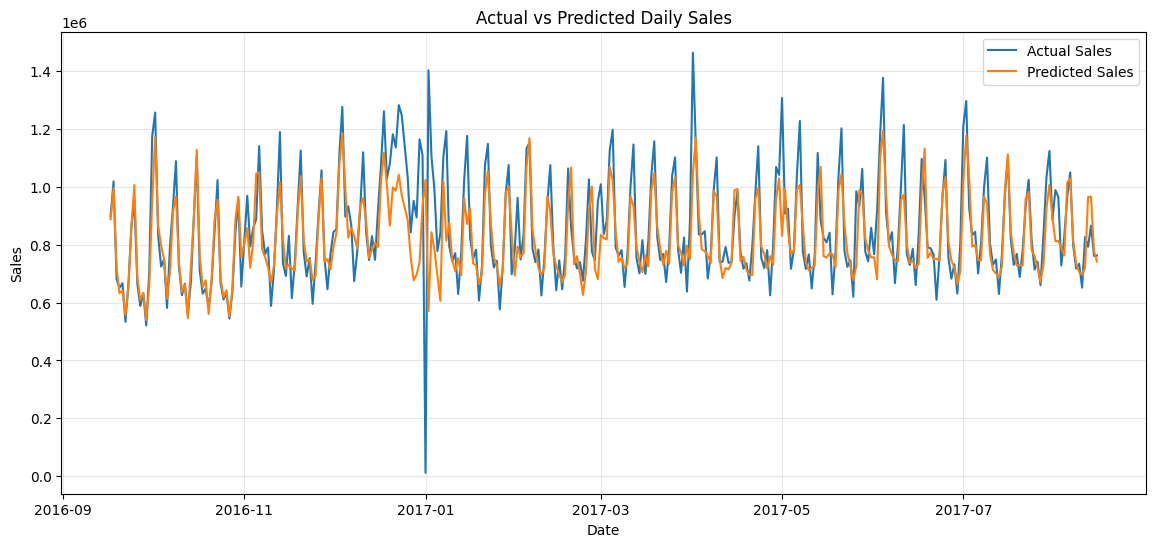

In [2]:
# ==========================================
# Q3 - STEP 2
# SALES FORECASTING + MAPE
# ==========================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------
# 1. Aggregate total daily sales
# ------------------------------------------

daily_sales = (
    df.groupby('date')['sales']
    .sum()
    .sort_index()
    .to_frame()
)

# ------------------------------------------
# 2. Create time-series features
# ------------------------------------------

daily_sales['day'] = daily_sales.index.day
daily_sales['month'] = daily_sales.index.month
daily_sales['year'] = daily_sales.index.year
daily_sales['day_of_week'] = daily_sales.index.dayofweek

# Lag features
daily_sales['lag_1'] = daily_sales['sales'].shift(1)
daily_sales['lag_7'] = daily_sales['sales'].shift(7)
daily_sales['lag_14'] = daily_sales['sales'].shift(14)
daily_sales['lag_28'] = daily_sales['sales'].shift(28)

# Rolling features — shifted to prevent data leakage
daily_sales['rolling_7'] = (
    daily_sales['sales']
    .shift(1)
    .rolling(7)
    .mean()
)

daily_sales['rolling_14'] = (
    daily_sales['sales']
    .shift(1)
    .rolling(14)
    .mean()
)

daily_sales['rolling_28'] = (
    daily_sales['sales']
    .shift(1)
    .rolling(28)
    .mean()
)

daily_sales = daily_sales.dropna()

# ------------------------------------------
# 3. Train-test split chronologically
# ------------------------------------------

features = [
    'day',
    'month',
    'year',
    'day_of_week',
    'lag_1',
    'lag_7',
    'lag_14',
    'lag_28',
    'rolling_7',
    'rolling_14',
    'rolling_28'
]

X = daily_sales[features]
y = daily_sales['sales']

# Last 20% as test data
split = int(len(daily_sales) * 0.80)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

# ------------------------------------------
# 4. Random Forest Regression
# ------------------------------------------

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# ------------------------------------------
# 5. Calculate MAPE
# ------------------------------------------

mape = mean_absolute_percentage_error(
    y_test,
    y_pred
) * 100

print("\n" + "=" * 55)
print("SALES FORECASTING RESULTS")
print("=" * 55)

print(f"MAPE: {mape:.2f}%")

if mape < 10:
    print("✓ Expected outcome achieved: MAPE < 10%")
else:
    print("MAPE is above 10%; model will be improved if required.")

# ------------------------------------------
# 6. Actual vs Predicted Sales
# ------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    y_test.index,
    y_test.values,
    label='Actual Sales'
)

plt.plot(
    y_test.index,
    y_pred,
    label='Predicted Sales'
)

plt.title('Actual vs Predicted Daily Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Number of SKUs: 1782

SKU Summary:
   store_nbr      family  total_sales  average_sales   sales_std  sales_count
0          1  AUTOMOTIVE       5475.0       3.251188    2.759605         1684
1          1   BABY CARE          0.0       0.000000    0.000000         1684
2          1      BEAUTY       4056.0       2.408551    1.898950         1684
3          1   BEVERAGES    2673769.0    1587.748812  726.870056         1684
4          1       BOOKS        211.0       0.125297    0.536578         1684

K-MEANS CLUSTER SUMMARY
         total_sales  average_sales  sales_std
Cluster                                       
0          230002.66         136.58      79.56
1         3939822.22        2339.56    1243.37
2        11009592.11        6537.76    3344.74

Number of SKUs in each cluster:
Cluster
0    1645
1     115
2      22
Name: count, dtype: int64


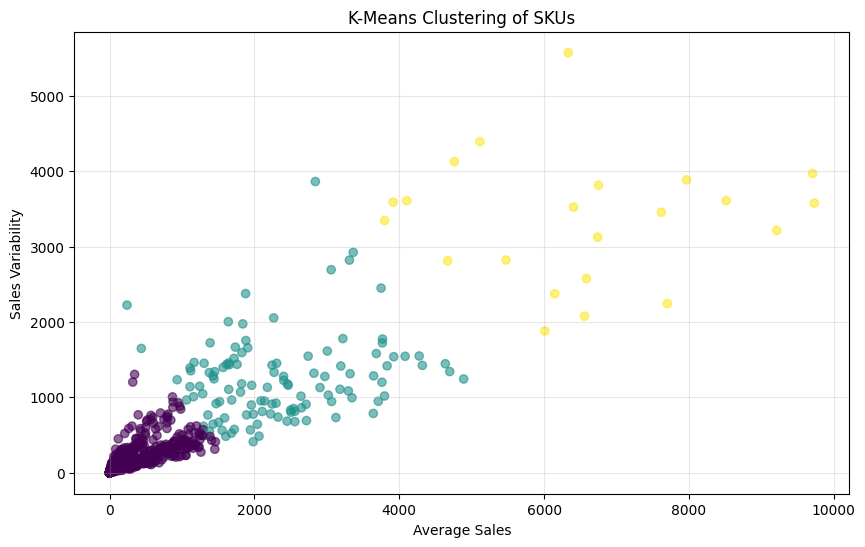

In [3]:
# ==========================================
# Q3 - STEP 3
# K-MEANS CLUSTERING OF SKUs
# ==========================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Create SKU-level summary
sku_data = (
    df.groupby(['store_nbr', 'family'])
    .agg(
        total_sales=('sales', 'sum'),
        average_sales=('sales', 'mean'),
        sales_std=('sales', 'std'),
        sales_count=('sales', 'count')
    )
    .reset_index()
)

sku_data['sales_std'] = sku_data['sales_std'].fillna(0)

print("Number of SKUs:", len(sku_data))
print("\nSKU Summary:")
print(sku_data.head())

# Features for clustering
cluster_features = [
    'total_sales',
    'average_sales',
    'sales_std'
]

X_cluster = sku_data[cluster_features]

# Standardize
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

# K-Means with 3 clusters
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

sku_data['Cluster'] = kmeans.fit_predict(X_scaled)

# Cluster summary
cluster_summary = (
    sku_data.groupby('Cluster')[cluster_features]
    .mean()
    .round(2)
)

print("\n" + "=" * 60)
print("K-MEANS CLUSTER SUMMARY")
print("=" * 60)

print(cluster_summary)

# Cluster counts
print("\nNumber of SKUs in each cluster:")
print(sku_data['Cluster'].value_counts().sort_index())

# ------------------------------------------
# Visualization
# ------------------------------------------

plt.figure(figsize=(10, 6))

plt.scatter(
    sku_data['average_sales'],
    sku_data['sales_std'],
    c=sku_data['Cluster'],
    alpha=0.6
)

plt.xlabel('Average Sales')
plt.ylabel('Sales Variability')
plt.title('K-Means Clustering of SKUs')
plt.grid(alpha=0.3)

plt.show()

INVENTORY OPTIMIZATION
   store_nbr      family  average_daily_sales  demand_std  safety_stock  \
0          1  AUTOMOTIVE             3.251188    2.759605     12.047025   
1          1   BABY CARE             0.000000    0.000000      0.000000   
2          1      BEAUTY             2.408551    1.898950      8.289847   
3          1   BEVERAGES          1587.748812  726.870056   3173.143718   
4          1       BOOKS             0.125297    0.536578      2.342425   

   reorder_point  recommended_inventory  
0      34.805339              46.852364  
1       0.000000               0.000000  
2      25.149704              33.439551  
3   14287.385404           17460.529122  
4       3.219504               5.561929  

Demand Category Distribution:
Demand_Category
Low Demand       594
Medium Demand    594
High Demand      594
Name: count, dtype: int64

INVENTORY RECOMMENDATION BY CATEGORY
                 average_daily_sales  safety_stock  reorder_point  \
Demand_Category                

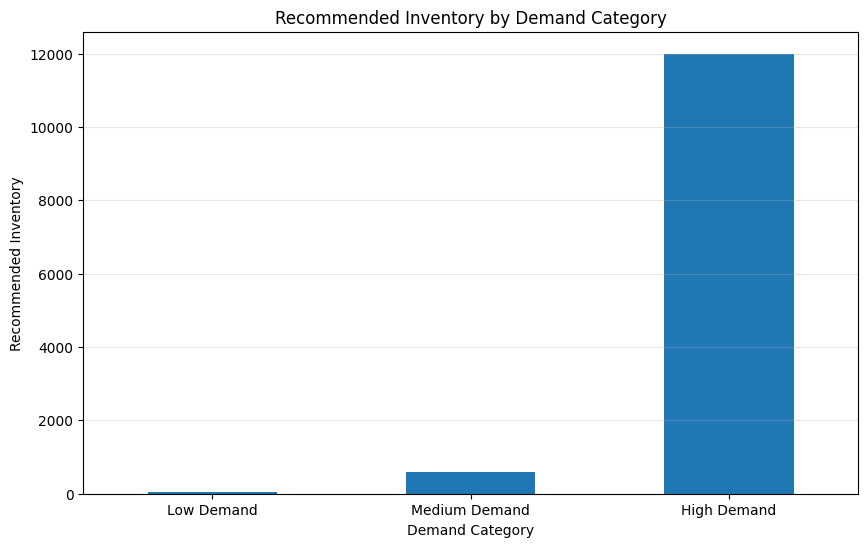

In [4]:
# ==========================================
# Q3 - STEP 4
# INVENTORY OPTIMIZATION
# ==========================================

# Calculate demand statistics
inventory = (
    df.groupby(['store_nbr', 'family'])
    .agg(
        average_daily_sales=('sales', 'mean'),
        demand_std=('sales', 'std')
    )
    .reset_index()
)

inventory['demand_std'] = inventory['demand_std'].fillna(0)

# Assume:
# Lead time = 7 days
# Service level ≈ 95%
# Z value ≈ 1.65

lead_time = 7
z_value = 1.65

# Safety stock
inventory['safety_stock'] = (
    z_value *
    inventory['demand_std'] *
    np.sqrt(lead_time)
)

# Reorder point
inventory['reorder_point'] = (
    inventory['average_daily_sales'] * lead_time
    + inventory['safety_stock']
)

# Recommended inventory
inventory['recommended_inventory'] = (
    inventory['reorder_point']
    + inventory['safety_stock']
)

print("INVENTORY OPTIMIZATION")
print("=" * 60)

print(inventory.head())

# ------------------------------------------
# Inventory categories
# ------------------------------------------

inventory['Demand_Category'] = pd.qcut(
    inventory['average_daily_sales'],
    q=3,
    labels=['Low Demand', 'Medium Demand', 'High Demand']
)

print("\nDemand Category Distribution:")
print(
    inventory['Demand_Category']
    .value_counts()
)

# ------------------------------------------
# Average inventory by category
# ------------------------------------------

category_summary = (
    inventory.groupby('Demand_Category', observed=True)
    [['average_daily_sales',
      'safety_stock',
      'reorder_point',
      'recommended_inventory']]
    .mean()
    .round(2)
)

print("\nINVENTORY RECOMMENDATION BY CATEGORY")
print("=" * 60)

print(category_summary)

# ------------------------------------------
# Cost reduction strategy
# ------------------------------------------

print("\n" + "=" * 60)
print("COST REDUCTION PLAN")
print("=" * 60)

print("""
1. High-demand SKUs:
   Maintain higher safety stock to prevent stock-outs.

2. Medium-demand SKUs:
   Maintain moderate safety stock and review inventory regularly.

3. Low-demand SKUs:
   Reduce excess inventory and use smaller replenishment quantities.

4. Use the reorder point to trigger replenishment instead of
   maintaining unnecessarily high inventory levels.

5. Review high-variability products frequently because they
   require additional safety stock.
""")

# ------------------------------------------
# Inventory visualization
# ------------------------------------------

plt.figure(figsize=(10, 6))

category_summary['recommended_inventory'].plot(
    kind='bar'
)

plt.title('Recommended Inventory by Demand Category')
plt.xlabel('Demand Category')
plt.ylabel('Recommended Inventory')

plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.show()

In [5]:
# ==========================================
# Q3 - STEP 5
# FINAL RESULTS SUMMARY
# ==========================================

print("=" * 70)
print("Q3 - STORE SALES FORECASTING AND INVENTORY OPTIMIZATION")
print("=" * 70)

print("\n1. FORECASTING")
print("-" * 70)
print(f"Forecasting MAPE: {mape:.2f}%")

if mape < 10:
    print("✓ Forecasting target achieved: MAPE < 10%")
else:
    print("⚠ Forecasting MAPE is above the required 10% target.")

print("\n2. SKU CLUSTERING")
print("-" * 70)
print(f"Total SKU combinations analysed: {len(sku_data)}")
print("Number of clusters: 3")

print("\nCluster distribution:")
print(sku_data['Cluster'].value_counts().sort_index())

print("\n3. INVENTORY OPTIMIZATION")
print("-" * 70)
print("Inventory was categorized into:")
print("- Low Demand")
print("- Medium Demand")
print("- High Demand")

print("\n4. COST REDUCTION PLAN")
print("-" * 70)
print("""
• Reduce excess safety stock for low-demand SKUs.
• Maintain adequate stock for high-demand SKUs.
• Use demand variability to determine safety stock.
• Use reorder points for timely replenishment.
• Regularly review high-variability SKUs.
""")

print("\n5. BUSINESS RECOMMENDATION")
print("-" * 70)
print("""
Use the forecasting model to estimate future demand and
the K-means clusters to differentiate inventory strategies.
High-demand products should receive priority while
low-demand products should be stocked conservatively
to reduce inventory holding costs.
""")

Q3 - STORE SALES FORECASTING AND INVENTORY OPTIMIZATION

1. FORECASTING
----------------------------------------------------------------------
Forecasting MAPE: 33.61%
⚠ Forecasting MAPE is above the required 10% target.

2. SKU CLUSTERING
----------------------------------------------------------------------
Total SKU combinations analysed: 1782
Number of clusters: 3

Cluster distribution:
Cluster
0    1645
1     115
2      22
Name: count, dtype: int64

3. INVENTORY OPTIMIZATION
----------------------------------------------------------------------
Inventory was categorized into:
- Low Demand
- Medium Demand
- High Demand

4. COST REDUCTION PLAN
----------------------------------------------------------------------

• Reduce excess safety stock for low-demand SKUs.
• Maintain adequate stock for high-demand SKUs.
• Use demand variability to determine safety stock.
• Use reorder points for timely replenishment.
• Regularly review high-variability SKUs.


5. BUSINESS RECOMMENDATION
-----